In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df=pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')
print(df.shape)
print(df.columns.tolist())
print(df.head(2))

(180519, 53)
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping d

In [3]:
#Select relevant columns
cols=['Type','Days for shipping (real)','Days for shipment (scheduled)',
      'Benefit per order','Sales per customer','Delivery Status',
      'Late_delivery_risk','Category Name','Customer Segment',
      'Customer Country','Market','order date (DateOrders)',
      'Order Id','Order Item Discount Rate','Order Item Quantity',
      'Sales','Order Item Total','Order Profit Per Order',
      'Order Region','Order Status','Product Name','Product Price',
      'Shipping Mode']

df=df[cols].copy()

#Rename for convenience
df.columns=['payment_type','shipping_days_real','shipping_days_scheduled',
            'benefit_per_order','sales_per_customer','delivery_status',
            'late_delivery_risk','category','customer_segment',
            'customer_country','market','order_date',
            'order_id','discount_rate','quantity',
            'sales','order_total','profit',
            'region','order_status','product','product_price',
            'shipping_mode']

#Convert date
df['order_date']=pd.to_datetime(df['order_date'])
df['year']=df['order_date'].dt.year
df['month']=df['order_date'].dt.month
df['year_month']=df['order_date'].dt.to_period('M')

#Delivery delay
df['delivery_delay']=df['shipping_days_real']-df['shipping_days_scheduled']
df['delivered_on_time']=(df['delivery_delay']<=0)

print("Shape:", df.shape)
print("\nNull counts:\n", df.isnull().sum())

Shape: (180519, 28)

Null counts:
 payment_type               0
shipping_days_real         0
shipping_days_scheduled    0
benefit_per_order          0
sales_per_customer         0
delivery_status            0
late_delivery_risk         0
category                   0
customer_segment           0
customer_country           0
market                     0
order_date                 0
order_id                   0
discount_rate              0
quantity                   0
sales                      0
order_total                0
profit                     0
region                     0
order_status               0
product                    0
product_price              0
shipping_mode              0
year                       0
month                      0
year_month                 0
delivery_delay             0
delivered_on_time          0
dtype: int64


## Core Analysis:

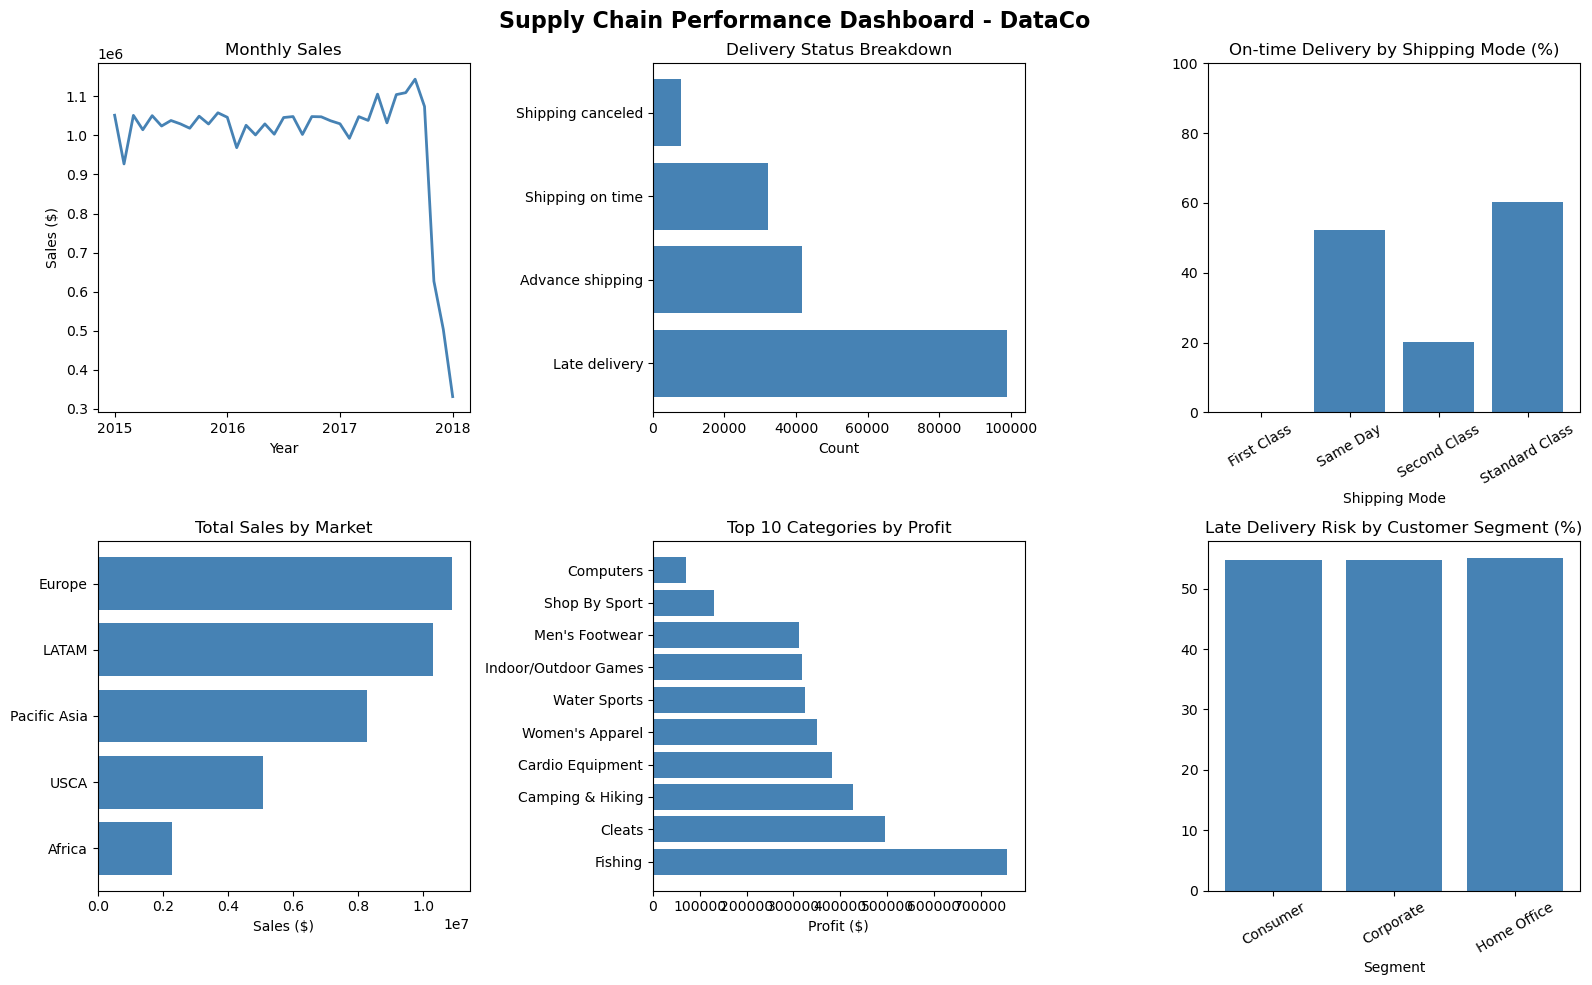

Saved.


In [5]:
fig, axes=plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Supply Chain Performance Dashboard - DataCo', fontsize=16, fontweight='bold')

#1. Sales trend over time
monthly_sales=df.groupby('year_month')['sales'].sum().reset_index()
monthly_sales['year_month']=monthly_sales['year_month'].astype(str)
axes[0,0].plot(monthly_sales['year_month'], monthly_sales['sales'], color='steelblue', linewidth=2)
axes[0,0].set_title('Monthly Sales')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Sales ($)')
jan_ticks=[i for i, ym in enumerate(monthly_sales['year_month']) if ym.endswith('-01')]
axes[0,0].set_xticks(jan_ticks)
axes[0,0].set_xticklabels([monthly_sales['year_month'].iloc[i][:4] for i in jan_ticks], rotation=0)

#2. Delivery status breakdown
delivery_counts=df['delivery_status'].value_counts()
axes[0,1].barh(delivery_counts.index, delivery_counts.values, color='steelblue')
axes[0,1].set_title('Delivery Status Breakdown')
axes[0,1].set_xlabel('Count')

#3. On-time delivery by shipping mode
ontime_by_mode=df.groupby('shipping_mode')['delivered_on_time'].mean()*100
axes[0,2].bar(ontime_by_mode.index, ontime_by_mode.values, color='steelblue')
axes[0,2].set_title('On-time Delivery by Shipping Mode (%)')
axes[0,2].set_xlabel('Shipping Mode')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].set_ylim(0, 100)

#4. Sales by market
sales_by_market=df.groupby('market')['sales'].sum().sort_values(ascending=True)
axes[1,0].barh(sales_by_market.index, sales_by_market.values, color='steelblue')
axes[1,0].set_title('Total Sales by Market')
axes[1,0].set_xlabel('Sales ($)')

#5. Top 10 categories by profit
profit_by_cat=df.groupby('category')['profit'].sum().sort_values(ascending=False).head(10)
axes[1,1].barh(profit_by_cat.index, profit_by_cat.values, color='steelblue')
axes[1,1].set_title('Top 10 Categories by Profit')
axes[1,1].set_xlabel('Profit ($)')

#6. Late delivery risk by customer segment
late_by_segment=df.groupby('customer_segment')['late_delivery_risk'].mean()*100
axes[1,2].bar(late_by_segment.index, late_by_segment.values, color='steelblue')
axes[1,2].set_title('Late Delivery Risk by Customer Segment (%)')
axes[1,2].set_xlabel('Segment')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('supplychain_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [6]:
#SQL analysis
df['year_month']=df['year_month'].astype(str)
conn=sqlite3.connect(':memory:')
df.to_sql('supply_chain', conn, index=False, if_exists='replace')

queries={
    'Sales & Profit by Market': """
        SELECT market,
               COUNT(DISTINCT order_id) as total_orders,
               ROUND(SUM(sales), 2) as total_sales,
               ROUND(SUM(profit), 2) as total_profit,
               ROUND(AVG(profit/NULLIF(sales,0))*100, 2) as profit_margin_pct
        FROM supply_chain
        GROUP BY market
        ORDER BY total_sales DESC
    """,
    'Late Delivery by Shipping Mode': """
        SELECT shipping_mode,
               COUNT(*) as total_orders,
               SUM(late_delivery_risk) as late_orders,
               ROUND(AVG(late_delivery_risk)*100, 1) as late_pct
        FROM supply_chain
        GROUP BY shipping_mode
        ORDER BY late_pct DESC
    """,
    'Top 5 Products by Revenue': """
        SELECT product,
               COUNT(*) as order_count,
               ROUND(SUM(sales), 2) as total_revenue,
               ROUND(AVG(product_price), 2) as avg_price
        FROM supply_chain
        GROUP BY product
        ORDER BY total_revenue DESC
        LIMIT 5
    """
}

for name, query in queries.items():
    print(f"\n--- {name} ---")
    print(pd.read_sql_query(query, conn))


--- Sales & Profit by Market ---
         market  total_orders  total_sales  total_profit  profit_margin_pct
0        Europe         18561  10872396.80    1169442.96              11.01
1         LATAM         17181  10277612.84    1123321.61              10.85
2  Pacific Asia         17577   8273743.74     857753.44              10.42
3          USCA          8579   5066528.71     564313.78              10.93
4        Africa          3854   2294452.93     252071.18              11.23

--- Late Delivery by Shipping Mode ---
    shipping_mode  total_orders  late_orders  late_pct
0     First Class         27814        26513      95.3
1    Second Class         35216        26987      76.6
2        Same Day          9737         4454      45.7
3  Standard Class        107752        41023      38.1

--- Top 5 Products by Revenue ---
                                         product  order_count  total_revenue  \
0      Field & Stream Sportsman 16 Gun Fire Safe        17325     6929653.69   


In [7]:
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

#1. Hypothesis test: does discount rate differ between late and on-time deliveries?
ontime_discount=df[df['delivered_on_time']==True]['discount_rate']
late_discount=df[df['delivered_on_time']==False]['discount_rate']

t_stat, p_value=stats.ttest_ind(ontime_discount, late_discount)
print("=== Hypothesis Test: Discount Rate vs Delivery Timeliness ===")
print(f"On-time mean discount: {ontime_discount.mean():.4f}")
print(f"Late mean discount: {late_discount.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significant difference: {p_value < 0.05}")

#2. Profit margin regression vs discount rate
corr, p_corr=stats.pearsonr(df['discount_rate'], df['profit'])
print(f"\n=== Correlation: Discount Rate vs Profit ===")
print(f"Pearson correlation: {corr:.4f}")
print(f"P-value: {p_corr:.6f}")

#3. Demand forecasting - monthly sales trend
monthly=df.groupby(['year','month'])['sales'].sum().reset_index()
monthly['time_index']=range(len(monthly))
X=monthly['time_index'].values.reshape(-1,1)
y=monthly['sales'].values

model=LinearRegression()
model.fit(X, y)
y_pred=model.predict(X)
mae=mean_absolute_error(y, y_pred)

print(f"\n=== Demand Forecasting — Linear Trend ===")
print(f"Monthly sales change: ${model.coef_[0]:.0f}")
print(f"R² score: {model.score(X, y):.4f}")
print(f"MAE: ${mae:.0f}")

#Forecast next 3 months
next_3=model.predict([[len(monthly)],[len(monthly)+1],[len(monthly)+2]])
print(f"\nForecasted sales next 3 months:")
for i, val in enumerate(next_3):
    print(f"Month +{i+1}: ${val:,.0f}")

=== Hypothesis Test: Discount Rate vs Delivery Timeliness ===
On-time mean discount: 0.1016
Late mean discount: 0.1017
T-statistic: -0.4236
P-value: 0.671854
Significant difference: False

=== Correlation: Discount Rate vs Profit ===
Pearson correlation: -0.0186
P-value: 0.000000

=== Demand Forecasting — Linear Trend ===
Monthly sales change: $-5187
R² score: 0.1214
MAE: $92900

Forecasted sales next 3 months:
Month +1: $895,636
Month +2: $890,450
Month +3: $885,263


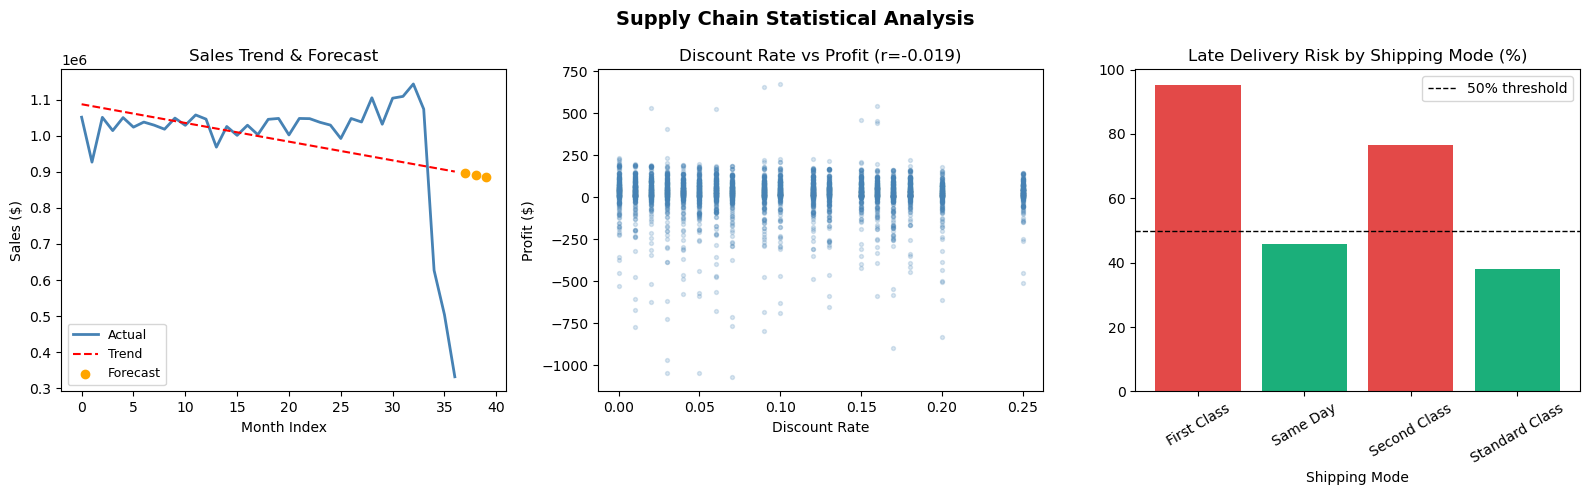

Saved.


In [8]:
fig, axes=plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Supply Chain Statistical Analysis', fontsize=14, fontweight='bold')

#1. Sales trend with forecast
monthly_plot=df.groupby(['year','month'])['sales'].sum().reset_index()
monthly_plot['time_index']=range(len(monthly_plot))
future_idx=[[len(monthly_plot)],[len(monthly_plot)+1],[len(monthly_plot)+2]]
forecast=model.predict(future_idx)

axes[0].plot(monthly_plot['time_index'], monthly_plot['sales'], color='steelblue', linewidth=2, label='Actual')
axes[0].plot(monthly_plot['time_index'], model.predict(monthly_plot['time_index'].values.reshape(-1,1)), color='red', linestyle='--', linewidth=1.5, label='Trend')
axes[0].scatter([f[0] for f in future_idx], forecast, color='orange', zorder=5, label='Forecast')
axes[0].set_title('Sales Trend & Forecast')
axes[0].set_xlabel('Month Index')
axes[0].set_ylabel('Sales ($)')
axes[0].legend(fontsize=9)

#2. Discount rate vs profit scatter
sample=df.sample(5000, random_state=42)
axes[1].scatter(sample['discount_rate'], sample['profit'], alpha=0.2, color='steelblue', s=8)
axes[1].set_title(f'Discount Rate vs Profit (r={corr:.3f})')
axes[1].set_xlabel('Discount Rate')
axes[1].set_ylabel('Profit ($)')

#3. Late delivery by shipping mode
modes=df.groupby('shipping_mode')['late_delivery_risk'].mean()*100
colors=['#e34948' if v>50 else '#1baf7a' for v in modes.values]
axes[2].bar(modes.index, modes.values, color=colors)
axes[2].set_title('Late Delivery Risk by Shipping Mode (%)')
axes[2].set_xlabel('Shipping Mode')
axes[2].tick_params(axis='x', rotation=30)
axes[2].axhline(50, color='black', linestyle='--', linewidth=1, label='50% threshold')
axes[2].legend()

plt.tight_layout()
plt.savefig('supplychain_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")